In [2]:
from pathlib import Path
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


PROJECT_DIR = Path("/home/rahul/projects/distributed-gpu-pipeline")
ARTIFACT_DIR = PROJECT_DIR / "mlartifacts"

mlflow.set_tracking_uri(f"sqlite:///{(PROJECT_DIR / 'mlflow.db').as_posix()}")
mlflow.set_experiment("CIFAR-10_Single-GPU")

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active Experiment: {mlflow.get_experiment_by_name("CIFAR-10_Single-GPU")}")

/home/rahul/projects/distributed-gpu-pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow Tracking URI: sqlite:////home/rahul/projects/distributed-gpu-pipeline/mlflow.db
Active Experiment: <Experiment: artifact_location='/home/rahul/projects/distributed-gpu-pipeline/notebooks/mlruns/1', creation_time=1788509768020, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788509768020, lifecycle_stage='active', name='CIFAR-10_Single-GPU', tags={}, trace_location=None, workspace='default'>


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torchvision.models import resnet18, ResNet18_Weights
import torchvision.models as models
import torch.nn as nn
import time

# Transformations 
data_statictics = ((0.5,0.5,0.5), (0.5,0.5,0.5))

transformed_train_images = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), #CxHxW
    transforms.Normalize(*data_statictics, inplace=True), #[-1, 1]
])

transformed_test_images = transforms.Compose([
    transforms.ToTensor(), #CxHxW
    transforms.Normalize(*data_statictics, inplace=True), #[-1, 1]
])

In [ ]:
# dataset and dataloaders 
# train dataset
train_dataset = torchvision.datasets.CIFAR10(
    root="../data/downloads", 
    download=True,
    train=True,
    transform=transformed_train_images
)

# validation split
total_size = len(train_dataset)
val_size = int(0.2 * total_size)
train_size = total_size - val_size 

train_split, val_split = random_split(
    train_dataset,
    [train_size,val_size]
)

val_dataset = torchvision.datasets.CIFAR10(
    root="../data/downloads",
    train=True,
    download=False,
    transform=transformed_test_images,
)

val_split = torch.utils.data.Subset(
    val_dataset,
    val_split.indices,
)

# test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root="../data/downloads", 
    download=True,
    train=False,
    transform=transformed_test_images
)

train_dataloader = torch.utils.data.DataLoader(
    dataset=train_split,
    batch_size=16,
    shuffle=True,
    pin_memory=True
)

val_dataloader = torch.utils.data.DataLoader(
    dataset=val_split,
    batch_size=16,
    shuffle=False,
    pin_memory=True
)

test_dataloader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=16,
    pin_memory=True
)

print(
    f"Train Data Size: {len(train_split)}"
    f"\nVal Data Size: {len(val_split)}"
    f"\nTest Data Size: {len(test_dataset)}" 
)

In [ ]:
# device selection
def get_device():
    if torch.cuda.is_available():
        print("Cuda is Available!!", torch.cuda.get_device_name())
        return torch.device("cuda:0")
    else:
        raise RuntimeError("CUDA is required for this GPU training run.")

device = get_device()

In [ ]:
## Model
# Load ResNet-18 with pre-trained ImageNet weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Extract the number of input features going into the final layer
num_features = model.fc.in_features

# Replace the final layer with a new one matching CIFAR-10 (10 classes)
model.fc = nn.Linear(num_features, 10)

# Optimize for 32x32 images
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()

model = model.to(device)

In [ ]:
# Training Parameters

params = {
    "model": "resnet18",
    "dataset": "CIFAR-10",
    "batch_size": train_dataloader.batch_size,
    "learning_rate": 1e-4,
    "epochs": 30,
    "optimizer": "Adam",
    "model_type": "resnet18",
    "gpu": torch.cuda.get_device_name(device),
    "pytorch_version": str(torch.__version__),
    "cuda_version": str(torch.version.cuda),
}

# Fine tuning the entire network using very low LR
optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"]) 

# criterion
criterion = nn.CrossEntropyLoss()

In [ ]:
## Train with mlflow

with mlflow.start_run(
    run_name='resnet-18-batch16',
    log_system_metrics=True,
) as run:

    run_id = run.info.run_id
    checkpoint_dir = PROJECT_DIR / "models" / run_id
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = checkpoint_dir / "best.pth"
    
    mlflow.log_params(params=params)
    epochs = params["epochs"]
    best_val_loss = float("inf")


    for epoch in range(epochs):
        train_losses = []  # Changed name slightly to avoid confusion
        val_losses = []

        torch.cuda.synchronize(device)
        torch.cuda.reset_peak_memory_stats(device)
        epoch_start = time.perf_counter()

        # Train
        model.train() # Tell model it is training (fixes batchnorm)
        for images, labels in train_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            optimizer.step() 

            train_losses.append(loss.item()) 

        avg_train_loss = sum(train_losses) / len(train_dataloader)    

        # Validation
        model.eval()
        with torch.no_grad():
            for images, labels in val_dataloader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_losses.append(loss.item()) 

        avg_val_loss = sum(val_losses) / len(val_dataloader)

        torch.cuda.synchronize(device)
        epoch_seconds = time.perf_counter() - epoch_start
        peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)


        ## log epoch mterics
        mlflow.log_metrics(
            {
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
                "train val time secs": epoch_seconds,
                "peak tensor memory mb": peak_memory_mb,
            },
            step=epoch,
        )

        # Log check points after every 5 epochs
        if (epoch+1) % 5 == 0:
            mlflow.pytorch.log_model(model, name=f"checkpoint_{epoch}", serialization_format="pickle")       

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Train loss: {avg_train_loss:.4f} "
            f"| Val loss: {avg_val_loss:.4f} "
            f"| Train + val time: {epoch_seconds:.2f}s "
            f"| Peak tensor memory: {peak_memory_mb:.1f} MiB"
        )


        # Save
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), checkpoint_path)

    # log the final model
    model_info = mlflow.pytorch.log_model(model, name= 'final_model', serialization_format="pickle")

In [ ]:
# evaluation
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

#Re-create the exact optimized model architecture
test_model = models.resnet18()
num_features = test_model.fc.in_features
test_model.fc = nn.Linear(num_features, 10)
test_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
test_model.maxpool = nn.Identity()

test_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
test_model = test_model.to(device)

with mlflow.start_run(run_id=run_id):
    test_model.eval()

    mlflow.pytorch.log_model(
        test_model,
        name="best_model",
        serialization_format="pickle",
    )

    mlflow.log_metric("best_val_loss", best_val_loss)
    mlflow.set_tag("test_checkpoint", "best_model")
    
    # Trackers for global and per-class metrics
    correct = 0
    total = 0
    class_correct = [0] * 10
    class_total = [0] * 10
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = test_model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predicted.cpu().tolist())
            
            # Calculate global accuracy components
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Calculate per-class accuracy components
            for i in range(len(labels)):
                label = labels[i].item()
                pred = predicted[i].item()
                if label == pred:
                    class_correct[label] += 1
                class_total[label] += 1

    overall_acc = (correct / total) * 100
    print(f"OVERALL TEST ACCURACY: {overall_acc:.2f}%")

    mlflow.log_metrics({
        "test_accuracy_percent": overall_acc,
        "test_samples": total,
    })

    for i in range(10):
        if class_total[i] > 0:
            class_acc = (class_correct[i] / class_total[i]) * 100
            mlflow.log_metric(f"test_accuracy_{classes[i]}_percent", class_acc)
            print(f" - Accuracy of {classes[i]:<10}: {class_acc:.2f}%")
        else:
            print(f" - Accuracy of {classes[i]:<10}: No samples found")

NameError: name 'classes' is not defined

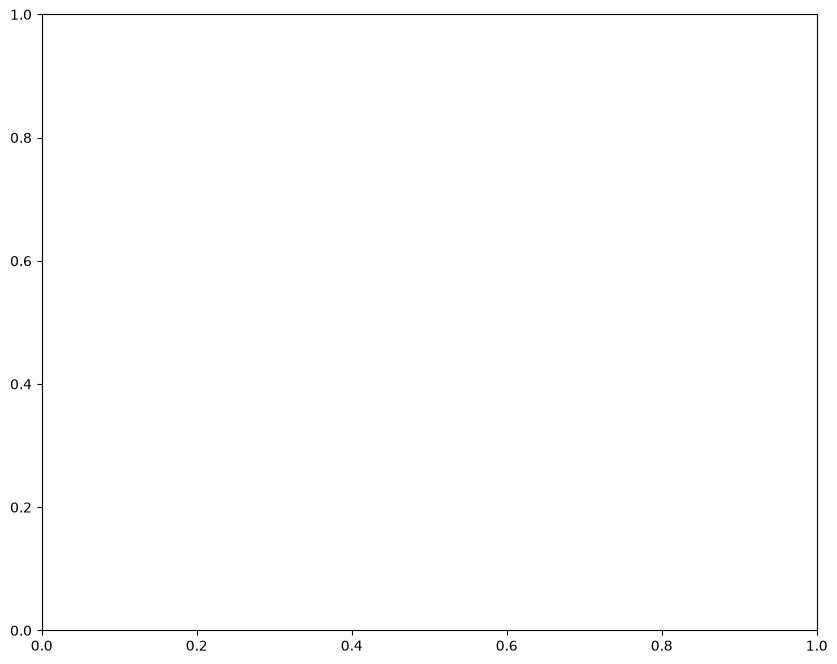

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_predictions,
    labels=list(range(10)),
    display_labels=classes,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title("CIFAR-10 — best checkpoint")
fig.tight_layout()

with mlflow.start_run(run_id=run_id):
    mlflow.log_figure(fig, "plots/test_confusion_matrix.png")

plt.show()